In [58]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

Random Forest puro (validation set) -   MÉTODO EMBUTIDO

Acurácia: 0.88
Matriz de confusão:
[[89 10]
 [14 87]]
Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        99
           1       0.90      0.86      0.88       101

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



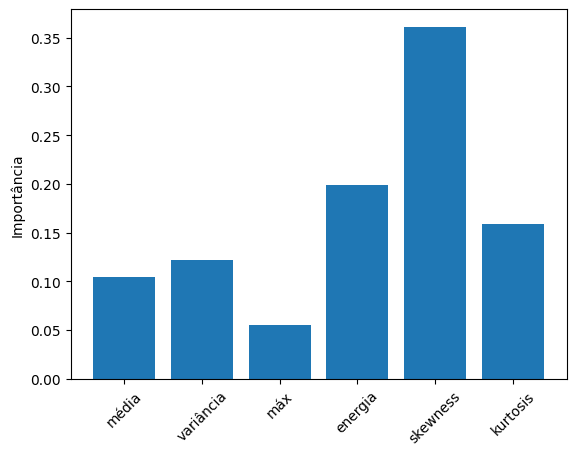

In [59]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

modelo = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=0)

modelo.fit(X_train,Y_train)

Y_predict = modelo.predict(X_test)

print('Acurácia:',accuracy_score(Y_test,Y_predict))

print('Matriz de confusão:')
print(confusion_matrix(Y_test,Y_predict))

print('Report:')
print(classification_report(Y_test,Y_predict))

nomes = ['média','variância','máx','energia','skewness','kurtosis']

imp = modelo.feature_importances_

plt.bar(nomes,imp)
plt.ylabel("Importância")
plt.xticks(rotation=45)
plt.show()


K-Fold sem seleção

In [60]:
modelo = RandomForestClassifier(n_estimators=100,criterion='entropy',max_depth=None,random_state=0)
cv = KFold(n_splits=10,shuffle=True,random_state=0)

X = df.drop(columns='Label')
Y = df['Label']

scores = cross_val_score(modelo,X,Y,cv=cv,scoring='accuracy')

print(scores)
print('Acuracia média',scores.mean())

[0.85 0.92 0.88 0.9  0.93 0.9  0.93 0.93 0.92 0.81]
Acuracia média 0.897


Seleção de atributos - Informação mútua

In [61]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

modelo = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=0)

seletor = SelectKBest(mutual_info_classif,k=3)

X_mi = seletor.fit_transform(X_train,Y_train)

print(seletor.scores_)
#print(seletor.get_support())

colunas_selecionadas = X_train.columns[seletor.get_support()]
print(colunas_selecionadas)

#display(X_mi)

[0.14236437 0.2987571  0.         0.2700528  0.35952615 0.20844035]
Index(['Variância', 'Energia', 'Skewness'], dtype='object')


Fazendo uma pipeline: Primeiro o dataset original é divivido em 10 folds. Dentro de cada fold é realizado uma seleção de atributos e então o modelo é treinado.

In [67]:
pipe = Pipeline([('seleção',SelectKBest(mutual_info_classif,k=3)),
                  ('modelo',RandomForestClassifier(n_estimators=100,max_depth=None,criterion='entropy',random_state=0))])

cv = KFold(n_splits=10,shuffle=True,random_state=0)

scores = cross_validate(pipe,X,Y,cv=cv,scoring=['f1','accuracy'])

print('Acurácia:',scores['test_accuracy'].mean())


Acurácia: 0.866
